# McGill COMP551, MINI-PROJECT 3: Odd-One-Out Image Groups

Aahaan Rawal (261177775) - aahaanrawal

Ian Gifford (261198495) - iangifford8

Nathan Hu (261147733) - nhucanada

**Kaggle group name: Group 67**


# Kaggle Competition
Training and test data are available as part of the assignment in the `datasets` folder. To participate in the competition you should upload a CSV file containing your predicted labels for the entire test data to Kaggle.

The test data is divided in half. You receive the correct labels for the first half (in the `datasets` folder), so that you can evaluate your model in this notebook on that part of the test set. You then submit your solution for the entire test set to Kaggle. The final evaluation is based on your predictions for the second half of the test set (private leaderboard). We have step-by-step explanation in the final section of this notebook.


# Report
The purpose of this notebook is for you to provide a concise high level code of your methodology. That is, you need to include all steps necessary to reproduce your results. Please include a high-level explanation of the implementation so that we can understand what you're trying to achieve in each piece of the code. You can import python code here if needed, in order to keep the notebook concise.

**Note:** You need to submit this notebook where you have run all the cells as part of the assignment. **We should not need to rerun your code since this can take a long time.**


## Step 1 — The Dataset
Use the following code to load the data using the npy files. We have **3,000 training examples**, where each example is a group of **5 grayscale images** (each 32×32). In each group:
- **4 images** share a hidden common property, and
- **1 image** is the **outlier**.

You do **not** have access to the underlying attributes. Your task is to learn to identify the **index** of the outlier image (a 5-class classification problem, with labels in {0, 1, 2, 3, 4}). The label is printed above each group shown below.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.load('datasets/x_train.npy')  # (3000, 5, 32, 32) — 3000 groups of 5 images each
y = np.load('datasets/y_train.npy')  # (3000,) — index of the outlier image in each group (0-4)

print(f'Training set: {x.shape[0]} groups, each with {x.shape[1]} images of size {x.shape[2]}x{x.shape[3]}')
print(f'Labels: values in {np.unique(y)}')

Training set: 3000 groups, each with 5 images of size 32x32
Labels: values in [0 1 2 3 4]


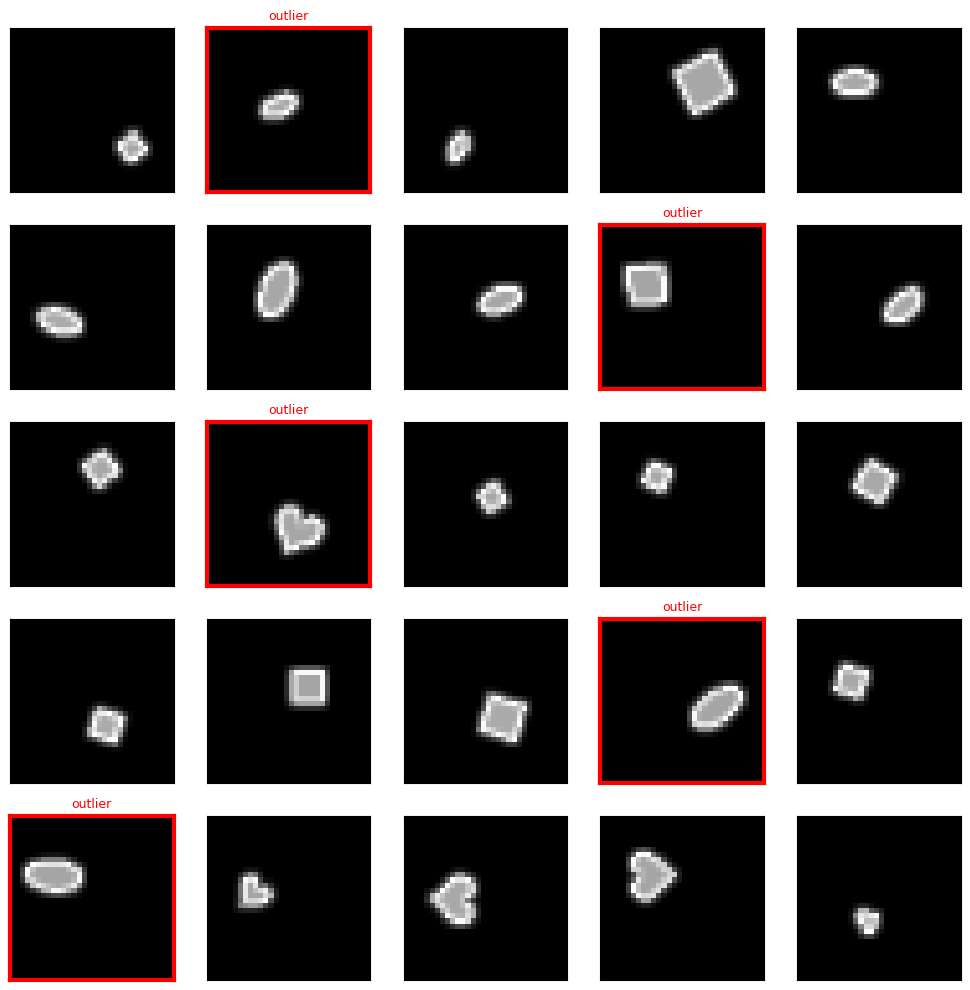

In [ ]:
def plot_groups(x, y, num_groups=5):
    """Plot groups of 5 images. The outlier is highlighted with a red border."""
    fig, axes = plt.subplots(num_groups, 5, figsize=(10, 2 * num_groups))
    for i in range(num_groups):
        for j in range(5):
            axes[i, j].imshow(x[i, j], cmap='gray')
            axes[i, j].set_xticks([])
            axes[i, j].set_yticks([])
            if j == y[i]:
                for spine in axes[i, j].spines.values():
                    spine.set_edgecolor('red')
                    spine.set_linewidth(3)
                axes[i, j].set_title('outlier', color='red', fontsize=9)
    plt.tight_layout()
    plt.show()

plot_groups(x, y, num_groups=5)

## Step 2 — Example: Logistic Regression Baseline
Below we apply a simple logistic regression to the flattened input as a demonstration. This model treats the entire group of 5 images as one flat vector and does not use any deep learning.

Note that **random chance** for this 5-class problem is **20%** (1/5).
As you can see, the logistic regression baseline performs close to random chance — you are expected to do significantly better using a deep learning model implemented in PyTorch (or Jax/TensorFlow).

In [ ]:
%%script false --no-raise-error

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

features = x.reshape(x.shape[0], -1)  # flatten each group of 5 images into a single vector
labels = y

x_train, x_val, y_train, y_val = train_test_split(features, labels, test_size=0.33, random_state=42)

clf = LogisticRegression(max_iter=1000)
clf.fit(x_train, y_train)

predictions = clf.predict(x_val)
accuracy = accuracy_score(y_val, predictions)
print(f'The validation accuracy of the baseline model is {accuracy * 100:.2f}%')

## Step 3 — Your Model
This is the main part of your report. Provide your model implementation, training code, and explanation below. Details should include the architecture, choice of hyperparameters, and any preprocessing or augmentation you applied. If you performed a hyperparameter search, explain it here.

**Important:** Your model must have at most **25,000** trainable parameters. You **must** uncomment and run the cell below to print and verify the parameter count. This count must also appear in your report.

### Preprocessing

**1. Tensor Conversion, Normalization, Standardization**

Input arrays are converted to PyTorch tensors, and pixel values are rescaled to [0, 1] and standardized based on the entire dataset's statistics. In the case of creating a validation or test dataset, standardization can be done based on a training dataset's statistics.

**2. Channel Dimension**

A channel dimension is added for CNN compatibility:

$$ (N, 5, 32, 32) → (N, 5, 1, 32, 32) $$

**3. Data Augmentation** (during training)

To increase variability and improve generalization, we implement a group of augmentations and permute image order:

(i) Rotation: All 5 images in a group are rotated by the same multiple of 90°.

(ii) Reflection: All 5 images in a group are flipped horizontally and/or vertically.

(iii) Translation: All 5 images are translated by at most 2 pixels vertically and horizontally.

(iv) Gaussian Noise: zero-mean gaussian noise with standard deviation 0.05 is added pixelwise.

The first three augmentations preserve relative structure among the 5 images while increasing variability. Gaussian noise acts as a regularizer by making the model less sensitive to exact pixel values.

Finally, if permutation is enabled, the 5 images are reordered randomly, and the new position of the outlier is reflected in the label. This discourages the model from learning positional bias and enforces that the predictions depend on image content rather than index.

The stored dataset remains static; augmentation and permutation are applied dynamically in \_\_getitem\_\_ during training when using a DataLoader. This means that between epochs, the model is exposed to slightly different input each time.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import copy
from sklearn.model_selection import ParameterGrid, StratifiedKFold
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Notice there is no major class imbalance and all pixel values are within [0, 255].

In [ ]:
print(f"Class distribution: {np.bincount(y)}")
print(f"x.min(): {x.min()}, x.max(): {x.max()}")

Class distribution: [616 544 588 645 607]
x.min(): 0, x.max(): 255


In [ ]:
class CustomDataset(Dataset):
  # x[i]: (5, 32, 32) -> 5 grayscale images
  # y[i]: value in {0, 1, 2, 3, 4} indicating outlier

  # pass y=None if labels are unknown
  def __init__(self, x, y, mean=None, std=None, augment=True, permute=True):
    self.x = torch.tensor(x, dtype=torch.float32) # shape (N, 5, 32, 32)
    self.y = None if y is None else torch.tensor(y, dtype=torch.long)    # shape (N,)
    self.augment = augment
    self.permute = permute

    # normalize to range [0, 1]
    if self.x.max() > 1.0:
      self.x = self.x / 255.0

    # add for grayscale channel dimension
    self.x = self.x.unsqueeze(2) # shape (N, 5, 1, 32, 32)

    # if mean or std are None, standardize on entire dataset
    # otherwise, standardize on given mean and std
    if mean is None or std is None:
      self.mean = self.x.mean()
      self.std = self.x.std().clamp_min(1e-6)
    else:
      self.mean = mean
      self.std = std
    self.x = (self.x - self.mean) / self.std

  def __len__(self):
    return len(self.x)

  # helper function to translate imgs by tx and ty
  def _translate(self, imgs, tx, ty):
    # expects imgs (5, 1, H, W)
    _, _, H, W = imgs.shape

    pad_left = max(tx, 0)
    pad_right = max(-tx, 0)
    pad_top = max(ty, 0)
    pad_bottom = max(-ty, 0)

    imgs = F.pad(imgs, (pad_left, pad_right, pad_top, pad_bottom), mode="reflect")

    x_start = pad_right
    y_start = pad_bottom
    imgs = imgs[:, :, y_start:y_start + H, x_start:x_start + W]

    return imgs

  def __getitem__(self, idx):
    imgs = self.x[idx].clone()

    # no permutation or augmentation if y=None
    if self.y is None:
      return imgs

    label = self.y[idx].item()

    if self.augment:
      # random rotation
      k = torch.randint(0, 4, (1,)).item()
      imgs = torch.rot90(imgs, k=k, dims=(-2, -1))

      # random reflections
      if torch.rand(1).item() < 0.5:
        imgs = torch.flip(imgs, dims=(-1,))
      if torch.rand(1).item() < 0.5:
        imgs = torch.flip(imgs, dims=(-2,))

      # random translation by max 2 pixels
      tx = torch.randint(-2, 3, (1,)).item()
      ty = torch.randint(-2, 3, (1,)).item()
      imgs = self._translate(imgs, tx, ty)

      # gaussian noise
      noise_std = 0.05
      noise = torch.randn_like(imgs) * noise_std
      imgs = imgs + noise

    # randomly permute the 5 images and update label
    if self.permute:
      perm = torch.randperm(5)
      imgs = imgs[perm]
      label = (perm == label).nonzero(as_tuple=True)[0].item()

    return imgs, torch.tensor(label, dtype=torch.long)

### Model Architecture

**1. Shared CNN Encoder**

The model uses a shared CNN encoder to map each input image to an embedding vector. The encoder consists of four convolutional blocks with Group Normalization and GELU activations, progressively reducing spatial resolution while increasing feature depth. The final linear projection produces a fixed-dimensional embedding for each image.

**2. MLP Comparison Head**

The 5 images are compared to determine which one is the most different from the others. For each image $i$, we compare its embedding vector to the distribution of the 4 other embeddings. We summarize the other images using their mean and variance and construct the following feature representation:

$$[e_i, \mu_{-i}, |e_i-\mu_{-i}|, \sigma^2_{-i}]$$

where $\mu_{-i}$ and $\sigma^2_{-i}$ are the mean and variance of the embeddings of the other 4 images.

This representation is meant to capture how much image $i$ deviates from the typical embedding of the group.

The resulting feature vector is passed through a small MLP to produce a single score (scalar) indicating how likely image $i$ is to be the outlier.

For each instance, the model outputs 5 scores, which we treat as logits passed into CrossEntropyLoss.

In [ ]:
class CNNEncoder(nn.Module):
  def __init__(self, embedding_dim=24):
    super().__init__()

    self.features = nn.Sequential(
        # input: (B, 1, 32, 32)
        nn.Conv2d(1, 12, kernel_size=5, stride=1, padding=2, bias=False),
        nn.GroupNorm(3, 12),
        nn.GELU(),
        # output: (B, 12, 32, 32)

        nn.Conv2d(12, 20, kernel_size=3, stride=2, padding=1, bias=False),
        nn.GroupNorm(4, 20),
        nn.GELU(),
        # output: (B, 20, 16, 16)

        nn.Conv2d(20, 24, kernel_size=3, stride=1, padding=1, bias=False),
        nn.GroupNorm(4, 24),
        nn.GELU(),
        # output: (B, 24, 16, 16)

        nn.Conv2d(24, 24, kernel_size=3, stride=2, padding=1, bias=False),
        nn.GroupNorm(4, 24),
        nn.GELU(),
        # output: (B, 24, 8, 8)

        nn.AdaptiveAvgPool2d((2, 2))
        # output: (B, 24, 2, 2)
    )

    self.proj = nn.Linear(24 * 2 * 2, embedding_dim)

    self.init_weights()

  def init_weights(self):
    # initialize weights using Kaiming He
    for m in self.modules():
      if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        if m.bias is not None:
          nn.init.zeros_(m.bias)
      elif isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        nn.init.zeros_(m.bias)
      elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
        nn.init.ones_(m.weight)
        nn.init.zeros_(m.bias)

  def forward(self, x):
    x = self.features(x) # -> (B, 24, 2 2)
    x = x.flatten(1)     # -> (B, 96)
    x = self.proj(x)     # -> (B, embedding_dim)

    return x

In [ ]:
class OddOneOutNet(nn.Module):
  def __init__(self, embedding_dim=24, hidden_dim=40):
    super().__init__()

    # encodes each image into an embedding vector
    self.encoder = CNNEncoder(embedding_dim=embedding_dim)

    # [e_i, mean(others), |e_i-mean(others)|, var(others)]
    scorer_in = 4 * embedding_dim

    self.scorer = nn.Sequential(
        nn.Linear(scorer_in, hidden_dim),
        nn.GELU(),
        nn.Linear(hidden_dim, 1)
    )

    self.init_weights()

  def init_weights(self):
    # initialize weights using Kaiming He
    for m in self.modules():
      if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        nn.init.zeros_(m.bias)

  def forward(self, x):
    # input: (B, 5, 1, 32, 32)
    # output: logits (B, 5)

    B, N, C, H, W = x.shape

    x = x.view(B * N, C, H, W)            # -> (B*5, 1, 32, 32)
    embeddings = self.encoder(x)          # -> (B*5, D)
    D = embeddings.shape[-1]
    embeddings = embeddings.view(B, N, D) # -> (B, 5, D)

    scores = []

    # score each i_th image by comparing it to the other 4
    for i in range(N): # N = 5
      e_i = embeddings[:, i, :]   # -> (B, D)

      others = torch.cat([embeddings[:, :i, :], embeddings[:, i+1:, :]], dim=1) # (B, 4, D)
      mean_others = others.mean(dim=1) # (B, D)
      var_others = others.var(dim=1, unbiased=False) # (B, D)

      feat = torch.cat([
        e_i,
        mean_others,
        torch.abs(e_i - mean_others),
        var_others
      ], dim=-1)

      score_i = self.scorer(feat)  # (B,1)
      scores.append(score_i)

    logits = torch.cat(scores, dim=1)  # (B,5)

    return logits

In [ ]:
# ============================================================
# REQUIRED: Print the number of trainable parameters in your model.
# Replace `model` with the name of your PyTorch model.
# This cell MUST appear with its output in your submitted notebook.
# ============================================================
model = OddOneOutNet()

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total trainable parameters: {total_params:,}')
assert total_params <= 25_000, f'Model too large! {total_params:,} > 25,000'

Total trainable parameters: 18,373


### Hyperparameter Search with Cross Validation

Hyperparameters were selected using 3-fold stratified cross validation. For each configuration, the model was trained on the training split and evaludated on the validation split, using early stopping based on validation loss to prevent overfitting. The final performance for each configuration was computed as the mean validation loss and accuracy across folds.

The best performing hyperparameters were chosen based on hte lowest mean validation loss. The selected configuration achieved a mean validation loss of 0.4118 and an accuracy of 0.8887.

The following hyperparameters were used for the final model training:

{batch_size=32, embedding_dim=24, epochs=100, label_smoothing=0.02, lr=0.005, hidden_dim=40, patience=10, scheduler=cosine, weight_decay=1e-4}

#### Helper functions

The following helper functions / classes are used in the cross validation pipeline:
- evaluate(model, loader, device, criterion)
- make_scheduler(optimizer, scheduler_name, epochs)
- EarlyStopping
- train_one_fold(x_train, y_train, x_val, y_val, params)

In [ ]:
# evaluates a model on a given dataset
# returns accuracy and average loss
def evaluate(model, loader, device, criterion=None):
  model.eval()
  total = 0
  correct = 0
  total_loss = 0.0

  with torch.no_grad():
    for imgs, y in loader:
      imgs = imgs.to(device)
      y = y.to(device)

      logits = model(imgs)

      if criterion is not None:
        loss = criterion(logits, y)
        total_loss += loss.item() * imgs.size(0)

      preds = logits.argmax(dim=1)
      correct += (preds == y).sum().item()
      total += y.size(0)

  acc = correct / total
  avg_loss = total_loss / total if criterion is not None else None
  return {"acc": acc, "loss": avg_loss}

In [ ]:
# initializes a scheduler for cross validation
# either cosine, step, or none
def make_scheduler(optimizer, scheduler_name, epochs):
  if scheduler_name == "cosine":
    return torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
  elif scheduler_name == "step":
    step_size = max(epochs // 3, 1)
    return torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=0.5)
  else:
    return None

In [ ]:
# early stopping mechanism used in cross validation and final training run with early stopping
class EarlyStopping:
  def __init__(self, mode='min', patience=10, min_delta=0.0):
    self.mode = mode
    self.patience = patience
    self.min_delta = min_delta
    self.best_score = None
    self.best_state = None
    self.counter = 0 # counts number of bad epochs

  # returns True if early stopping triggered
  # returns False if early stopping not triggered
  def step(self, score, model):
    improved = False

    if self.best_score is None:
      improved = True
    elif self.mode == 'max' and score > self.best_score + self.min_delta:
      improved = True
    elif self.mode == 'min' and score < self.best_score - self.min_delta:
      improved = True

    if improved:
      self.best_score = score
      self.best_state = copy.deepcopy(model.state_dict())
      self.counter = 0
    else:
      self.counter += 1

    return self.counter >= self.patience

In [ ]:
# trains one fold during cross validation
def train_one_fold(x_train, y_train, x_val, y_val, params):

  train_dataset = CustomDataset(
      x_train,
      y_train,
      augment=True,
      permute=True
  )

  # validation set standardized using train statistics
  val_dataset = CustomDataset(
      x_val,
      y_val,
      mean=train_dataset.mean,
      std=train_dataset.std,
      augment=False,
      permute=False
  )

  train_loader = DataLoader(
    train_dataset,
    batch_size=params["batch_size"],
    shuffle=True,
  )

  val_loader = DataLoader(
    val_dataset,
    batch_size=params["batch_size"],
    shuffle=False,
  )

  # set hyperparameters
  model = OddOneOutNet(params["embedding_dim"], params["hidden_dim"]).to(device)
  criterion = nn.CrossEntropyLoss(label_smoothing=params["label_smoothing"])
  optimizer = torch.optim.Adam(
      model.parameters(),
      lr=params["lr"],
      weight_decay=params["weight_decay"]
  )
  scheduler = make_scheduler(optimizer, params["scheduler"], params["epochs"])
  stopper = EarlyStopping(
      patience=params["patience"],
      min_delta=1e-4,
      mode="min"
  )

  # train model
  for epoch in range(params["epochs"]):
    model.train()

    for imgs, y in train_loader:
      imgs = imgs.to(device, non_blocking=True)
      y = y.to(device, non_blocking=True)

      optimizer.zero_grad()
      logits = model(imgs)
      loss = criterion(logits, y)
      loss.backward()
      optimizer.step()

    if scheduler is not None:
      scheduler.step()

    val_metrics = evaluate(model, val_loader, device, criterion)
    should_stop = stopper.step(val_metrics["loss"], model)
    if should_stop:
      break

  model.load_state_dict(stopper.best_state)
  final_val = evaluate(model, val_loader, device, criterion)

  return {
      "best_val_acc": final_val["acc"],
      "best_val_loss": final_val["loss"]
  }

#### Cross validation

*note: the cross validation run is not shown here, but the results are discussed in the report*

In [ ]:
%%script false --no-raise-error

# hyperparameter search
search_space = {
  "embedding_dim": [24],
  "hidden_dim": [40],
  "batch_size": [32, 64, 128],
  "label_smoothing": [0.02],
  "lr": [5e-3, 1e-3, 7e-4],
  "weight_decay": [1e-4, 1e-5],
  "scheduler": ["cosine"],
  "epochs": [100],
  "patience": [10]
}

results = []
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=87)
best_params, lowest_loss = None, np.inf

for params in ParameterGrid(search_space):
  fold_losses = []
  fold_accs = []

  for fold, (train_idx, val_idx) in enumerate(skf.split(x, y), start=1):
    metrics = train_one_fold(
      x[train_idx], y[train_idx],
      x[val_idx], y[val_idx],
      params,
    )
    fold_losses.append(metrics["best_val_loss"])
    fold_accs.append(metrics["best_val_acc"])

  result = {
    **params,
    "mean_val_loss": float(np.mean(fold_losses)),
    "std_val_loss": float(np.std(fold_losses)),
    "mean_val_acc": float(np.mean(fold_accs)),
    "std_val_acc": float(np.std(fold_accs)),
  }
  results.append(result)

  print(
    f"Done: {params} | "
    f"loss={result['mean_val_loss']:.4f} | "
    f"acc={result['mean_val_acc']:.4f}"
  )

results_df = pd.DataFrame(results).sort_values("mean_val_loss", ascending=True).reset_index(drop=True)
best_row = results_df.iloc[0].to_dict()

print(results_df.head())

### Training

The model was trained using the Adam optimizer with cross-entropy loss and label smoothing. During initial training, a validation set was used to monitor performance, and early stopping was applied based on the validation loss to prevent overfitting. A cosine learning rate scheduler was used to adjust the learning rate over time.

To determine an appropriate number of training epochs, the model was trained multiple times with early stopping, and the epoch at which validation performance stabilized was recorded. Based on this, a fixed number of 100 epochs was selected.

Finally, a final model was retrained on the full training data (without a validation split) for the selected number of epochs. Training loss and accuracy were tracked across epochs, and the final trained model was used for evaluation.

#### Train/Validation Split Preprocessing

In [ ]:
# preprocess training and validation sets and convert into data loaders
def make_loaders(x_train, y_train, x_val, y_val, batch_size=32):
  train_dataset = CustomDataset(
      x_train,
      y_train,
      augment=True,
      permute=True
  )
  val_dataset = CustomDataset(
      x_val,
      y_val,
      mean=train_dataset.mean,
      std=train_dataset.std,
      augment=False,
      permute=False
  )
  train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
  )
  val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
  )

  # return training mean and std for later standardizing the test set
  return train_loader, val_loader, train_dataset.mean, train_dataset.std

#### Training Setup

In [ ]:
# define hyperparameters
weight_decay = 1e-4
lr = 5e-3
batch_size = 32
embedding_dim = 24
hidden_dim = 40
label_smoothing = 0.02
T_max = 200
patience = 10
min_delta = 1e-4
epochs = 200
val_ratio = 0.2

In [ ]:
# setup
x_train, x_val, y_train, y_val = train_test_split(
    x, y, test_size=val_ratio, random_state=101, stratify=y
)
train_loader, val_loader, TRAIN_MEAN, TRAIN_STD = make_loaders(x_train, y_train, x_val, y_val, batch_size=batch_size)
model = OddOneOutNet(embedding_dim, hidden_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=T_max
)
stopper = EarlyStopping(
    patience=patience,
    min_delta=min_delta,
    mode="min"
)

#### Training Loops

In [ ]:
# training loop with early stopping on validation set
# ran multiple times to get an estimate of number of epochs

train_losses = []
val_losses = []
val_accs = []

for epoch in range(1, epochs+1):
    model.train()
    running_train_loss = 0.0
    running_train_total = 0

    for imgs, labels in train_loader:
      imgs = imgs.to(device)
      labels = labels.to(device)

      optimizer.zero_grad()
      logits = model(imgs)
      loss = criterion(logits, labels)
      loss.backward()
      optimizer.step()

      running_train_loss += loss.item() * labels.size(0)
      running_train_total += labels.size(0)

    if scheduler is not None:
      scheduler.step()

    train_loss = running_train_loss / running_train_total
    train_losses.append(train_loss)

    val_metrics = evaluate(model, val_loader, device, criterion)
    val_losses.append(val_metrics["loss"])
    val_accs.append(val_metrics["acc"])

    print(
        f"Epoch {epoch:03d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_acc={val_metrics['acc']:.4f}"
    )

    should_stop = stopper.step(val_metrics["loss"], model)
    if should_stop:
      print(f'Early stopping triggered at epoch {epoch}.')
      break

model.load_state_dict(stopper.best_state)
best_val_metrics = evaluate(model, val_loader, device, criterion)
print(f"Best val acc: {best_val_metrics['acc']:.4f}")

Epoch 001 | train_loss=1.6148 | val_loss=1.6094 | val_acc=0.1983
Epoch 002 | train_loss=1.5997 | val_loss=1.5782 | val_acc=0.2883
Epoch 003 | train_loss=1.5833 | val_loss=1.5737 | val_acc=0.3000
Epoch 004 | train_loss=1.5773 | val_loss=1.5512 | val_acc=0.3233
Epoch 005 | train_loss=1.5711 | val_loss=1.5699 | val_acc=0.2950
Epoch 006 | train_loss=1.5642 | val_loss=1.5454 | val_acc=0.3117
Epoch 007 | train_loss=1.5564 | val_loss=1.5419 | val_acc=0.3000
Epoch 008 | train_loss=1.5476 | val_loss=1.5518 | val_acc=0.3067
Epoch 009 | train_loss=1.5519 | val_loss=1.5369 | val_acc=0.3017
Epoch 010 | train_loss=1.5497 | val_loss=1.5302 | val_acc=0.3050
Epoch 011 | train_loss=1.5493 | val_loss=1.5365 | val_acc=0.3217
Epoch 012 | train_loss=1.5410 | val_loss=1.5853 | val_acc=0.2850
Epoch 013 | train_loss=1.5400 | val_loss=1.5239 | val_acc=0.3067
Epoch 014 | train_loss=1.5368 | val_loss=1.5296 | val_acc=0.2950
Epoch 015 | train_loss=1.5404 | val_loss=1.5358 | val_acc=0.3067
Epoch 016 | train_loss=1.

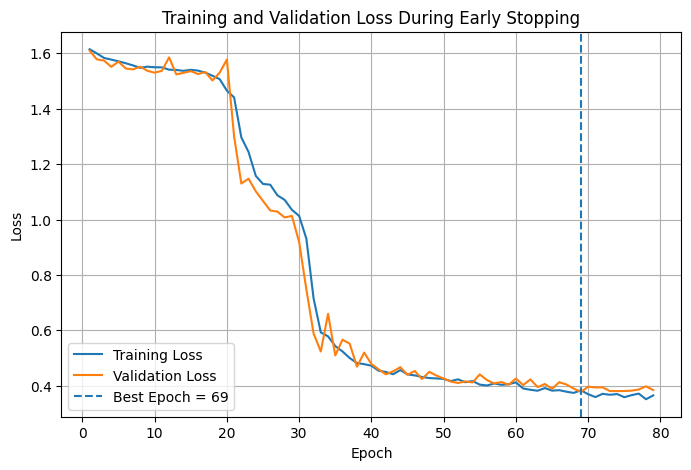

In [ ]:
# plot training and validation loss
epochs_ran = range(1, len(train_losses) + 1)
best_epoch = val_losses.index(min(val_losses)) + 1

plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, train_losses, label="Training Loss")
plt.plot(epochs_ran, val_losses, label="Validation Loss")
plt.axvline(best_epoch, linestyle="--", label=f"Best Epoch = {best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss During Early Stopping")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# train on entire training set with no validation set
# number of epochs determined from previous training loop
final_epochs = 100
T_max = 100

full_train_loader, _, FULL_TRAIN_MEAN, FULL_TRAIN_STD = make_loaders(
    x, y, x, y, batch_size=batch_size
)

model = OddOneOutNet(embedding_dim, hidden_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=T_max
)

for epoch in range(1, final_epochs + 1):
  model.train()
  running_loss = 0.0
  running_correct = 0
  running_total = 0

  for imgs, labels in full_train_loader:
    imgs = imgs.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()
    logits = model(imgs)
    loss = criterion(logits, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item() * labels.size(0)
    preds = logits.argmax(dim=1)
    running_correct += (preds == labels).sum().item()
    running_total += labels.size(0)

  if scheduler is not None:
    scheduler.step()

  train_loss = running_loss / running_total
  train_acc = running_correct / running_total

  print(
    f"Epoch {epoch:03d} | "
    f"train_loss={train_loss:.4f} | "
    f"train_acc={train_acc:.4f}"
  )

final_model = model

Epoch 001 | train_loss=1.6108 | train_acc=0.2180
Epoch 002 | train_loss=1.5824 | train_acc=0.2770
Epoch 003 | train_loss=1.5735 | train_acc=0.2923
Epoch 004 | train_loss=1.5640 | train_acc=0.3000
Epoch 005 | train_loss=1.5661 | train_acc=0.3040
Epoch 006 | train_loss=1.5544 | train_acc=0.3070
Epoch 007 | train_loss=1.5581 | train_acc=0.2953
Epoch 008 | train_loss=1.5450 | train_acc=0.3193
Epoch 009 | train_loss=1.5460 | train_acc=0.3197
Epoch 010 | train_loss=1.5194 | train_acc=0.3553
Epoch 011 | train_loss=1.4225 | train_acc=0.4400
Epoch 012 | train_loss=1.0888 | train_acc=0.6387
Epoch 013 | train_loss=0.7943 | train_acc=0.7750
Epoch 014 | train_loss=0.6372 | train_acc=0.8253
Epoch 015 | train_loss=0.5938 | train_acc=0.8297
Epoch 016 | train_loss=0.5143 | train_acc=0.8533
Epoch 017 | train_loss=0.5019 | train_acc=0.8573
Epoch 018 | train_loss=0.4937 | train_acc=0.8583
Epoch 019 | train_loss=0.4888 | train_acc=0.8593
Epoch 020 | train_loss=0.4865 | train_acc=0.8623
Epoch 021 | train_lo

## Step 4 — Accuracy Metrics and CSV Submission to Kaggle
At minimum, you **must** report in your submitted notebook:
1. The **number of trainable parameters** (printed in Step 3 above).
2. Your accuracy on the **first half of the test set** (public leaderboard).

**This accuracy must match your public leaderboard score on Kaggle.** If it does not, your leaderboard submission is discarded.

Below we show this evaluation for the logistic regression baseline. Note that the baseline accuracy is close to **random chance (20%)** — you should aim to do much better.

In [ ]:
# linear regression baseline
x_test = np.load('datasets/x_test.npy')        # (2000, 5, 32, 32) — 2000 test groups
x_test_half = x_test[:1000]                     # first half: you have the true labels
y_test_half = np.load('datasets/y_test.npy')    # (1000,) — true labels for the first half only

print(f'Test set: {x_test.shape[0]} groups total')
print(f'Public half: {x_test_half.shape[0]} groups (labels provided)')
print(f'Private half: {x_test.shape[0] - x_test_half.shape[0]} groups (labels hidden)\n')

#predictions = clf.predict(x_test_half.reshape(x_test_half.shape[0], -1))
#accuracy = accuracy_score(y_test_half, predictions)
#print(f'Public test accuracy (should match public leaderboard): {accuracy * 100:.2f}%')

Test set: 2000 groups total
Public half: 1000 groups (labels provided)
Private half: 1000 groups (labels hidden)



At inference, we apply label-preserving transformations (rotation, reflection, and permutations) to each input group and average the models' predictions across these views. This reduced variance and increased our test accuracy by 3% on average.

In [ ]:
# test-time augmentation: to reduce variance and increase accuracy
# average model predictions on augmented input during test-time
def predict_tta(model, imgs, num_perm_samples=0):
  logits_sum = 0
  count = 0

  spatial_versions = []
  for k in range(4):
    rotated = torch.rot90(imgs, k=k, dims=(-2,-1))
    spatial_versions.append(rotated)
    spatial_versions.append(torch.flip(rotated, dims=(-1,)))

  for x in spatial_versions:
    logits_sum += model(x)
    count += 1

    for _ in range(num_perm_samples):
      perm = torch.randperm(5, device=device)
      inv_perm = torch.argsort(perm)

      x_perm = x[:, perm]
      logits_perm = model(x_perm)
      logits_unperm = logits_perm[:, inv_perm]

      logits_sum += logits_unperm
      count += 1

  return logits_sum / count

In [ ]:
# ============================================================
# REQUIRED: Print your model's accuracy on the public test half.
# This number MUST match your public leaderboard score on Kaggle.
# Replace the code below with your own model's predictions.
# ============================================================

# public accuracy
from sklearn.metrics import accuracy_score

public_test_dataset = CustomDataset(
    x_test_half,
    y_test_half,
    mean=FULL_TRAIN_MEAN,
    std=FULL_TRAIN_STD,
    augment=False,
    permute=False
)
public_test_loader = DataLoader(public_test_dataset, batch_size=64)

final_model.eval()
preds, truths = [], []

with torch.no_grad():
    for imgs, y in public_test_loader:
        imgs = imgs.to(device)
        y = y.to(device)

        logits = predict_tta(final_model, imgs, num_perm_samples=4)
        pred = logits.argmax(1)

        preds.extend(pred.cpu().numpy())
        truths.extend(y.cpu().numpy())

accuracy = accuracy_score(truths, preds)
print(f'Public test accuracy (must match Kaggle public leaderboard): {accuracy * 100:.2f}%')

Public test accuracy (must match Kaggle public leaderboard): 80.30%


### Generating the CSV for Kaggle Submission
In order to submit your results to Kaggle you need to provide your predictions in CSV format. The code below shows how to do this for the logistic regression baseline above. You can use the same method for your submission.

Note that you need to submit your result for the **entire test set** of size **2,000**. Your accuracy on the first 1,000 will show on the public leaderboard and the remaining 1,000 are on the private leaderboard that will be revealed when the competition is over. Submit the `predicted_labels.csv` to the Kaggle competition!

In [ ]:
# predict on entire test set
test_dataset = CustomDataset(
    x_test,
    None,
    mean=FULL_TRAIN_MEAN,
    std=FULL_TRAIN_STD,
    augment=False,
    permute=False
)
test_loader = DataLoader(test_dataset, batch_size=64)

final_model.eval()
predictions = []
with torch.no_grad():
    for imgs in test_loader:
        imgs = imgs.to(device)

        logits = predict_tta(final_model, imgs, num_perm_samples=4)
        prediction = logits.argmax(1)

        predictions.extend(prediction.cpu().numpy())

In [ ]:
import pandas as pd

df = pd.DataFrame({"Id": np.arange(len(predictions)), "Category": predictions})
df.to_csv("predicted_labels.csv", index=False)
print(f'Saved {len(predictions)} predictions to predicted_labels.csv')

Saved 2000 predictions to predicted_labels.csv
